In [10]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Period & Domain

In [11]:
iyear=1960
fyear=2024
nx=10;ny=10
dom='GRp'
dom_NST = 'GRi'
year_NST = '2014'

# SF & RF & TF Data

In [12]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

# ICE mask

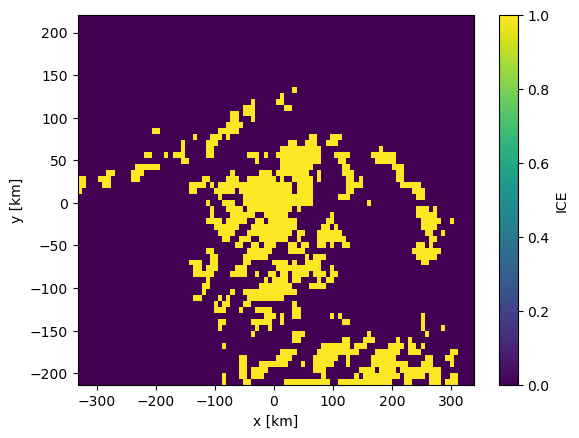

In [13]:
# ICE data
ds_grM= xr.open_dataset(f'/home/santolam/NST.{year_NST}.01.01.00.{dom_NST}.nc')
dsICE = ds_grM.ICE[ny:-ny,nx:-nx]

#ICE mask
ICE_mask = dsICE > 0
ICE_mask = ICE_mask.rename({'x': 'X', 'y': 'Y'})
ICE_mask.plot()

In [14]:
ICE_mask = ICE_mask.assign_coords({
    "X": RF.X,
    "Y": RF.Y
})
RF = RF.where(ICE_mask)

ICE_mask = ICE_mask.assign_coords({
    "X": SF.X,
    "Y": SF.Y
})
SF = SF.where(ICE_mask)

ICE_mask = ICE_mask.assign_coords({
    "X": TF.X,
    "Y": TF.Y
})
TF = TF.where(ICE_mask)

# Annual Mean

In [15]:
TF_mean = TF.groupby('time.year').mean('time', skipna=True)
TF_mean = TF_mean.mean(dim=['Y','X'], skipna=True)

SF_mean = SF.groupby('time.year').mean('time', skipna=True)
SF_mean = SF_mean.mean(dim=['Y','X'], skipna=True)

RF_mean = RF.groupby('time.year').mean('time', skipna=True)
RF_mean = RF_mean.mean(dim=['Y','X'], skipna=True)

R_mean = RF_mean / SF_mean * 100

# Trends

In [16]:
mask = ~np.isnan(RF_mean.values)
slope_RF, intercept_RF, r_value_RF, p_value_RF, std_err_RF = stats.linregress(RF_mean['year'].values[mask], RF_mean.values[mask])
trend_RF = intercept_RF + slope_RF * RF_mean['year'].values

slope_SF, intercept_SF, r_value_SF, p_value_SF, std_err_SF = stats.linregress(SF_mean['year'].values, SF_mean.values)
trend_SF = intercept_SF + slope_SF * SF_mean['year'].values

slope_TF, intercept_TF, r_value_TF, p_value_TF, std_err_TF = stats.linregress(TF_mean['year'].values, TF_mean.values)
trend_TF = intercept_TF + slope_TF * TF_mean['year'].values

slope_R, intercept_R, r_value_R, p_value_R, std_err_R = stats.linregress(R_mean['year'].values, R_mean.values)
trend_R = intercept_R + slope_R * R_mean['year'].values

# Statistics

In [17]:
mean_RF = np.nanmean(RF_mean.values)
std_RF = np.nanstd(RF_mean.values)
min_RF = np.nanmin(RF_mean.values)
max_RF = np.nanmax(RF_mean.values)

mean_SF = np.nanmean(SF_mean.values)
std_SF = np.nanstd(SF_mean.values)
min_SF = np.nanmin(SF_mean.values)
max_SF = np.nanmax(SF_mean.values)

mean_TF = np.nanmean(TF_mean.values)
std_TF = np.nanstd(TF_mean.values)
min_TF = np.nanmin(TF_mean.values)
max_TF = np.nanmax(TF_mean.values)

mean_R = np.nanmean(R_mean.values)
std_R = np.nanstd(R_mean.values)
min_R = np.nanmin(R_mean.values)
max_R = np.nanmax(R_mean.values)

RF : 0.05 mm / year / decade (p=0.001) (10.6 %/decade) (std=49.4 %)

SF : 0.10 mm / year / decade (p=0.764) (0.3 %/decade) (std=14.3 %)

TF : 0.15 mm / year / decade (p=0.662) (0.4 %/decade) (std=14.3 %)

R : 0.14 % / decade (p=0.000) (std=0.6 %)



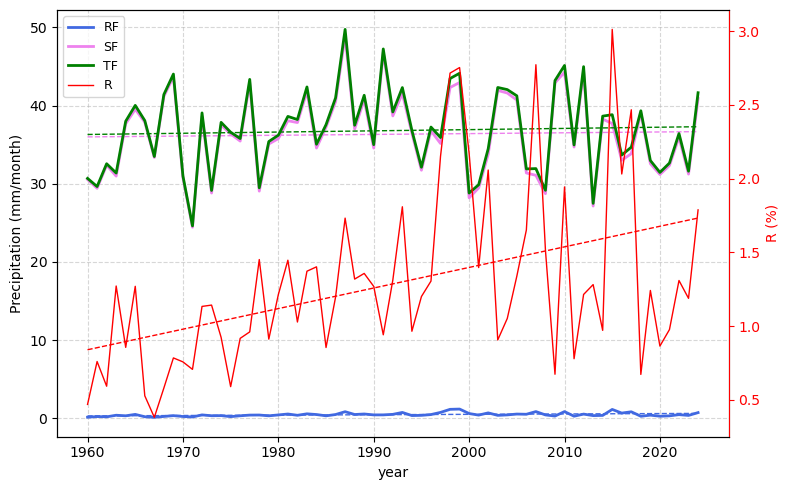

In [18]:
print(f'RF : {slope_RF * 10:.2f} mm / year / decade (p={p_value_RF:.3f}) ({(slope_RF*10)/mean_RF*100:.1f} %/decade) (std={std_RF/mean_RF*100:.1f} %)\n')
print(f'SF : {slope_SF * 10:.2f} mm / year / decade (p={p_value_SF:.3f}) ({(slope_SF*10)/mean_SF*100:.1f} %/decade) (std={std_SF/mean_SF*100:.1f} %)\n')
print(f'TF : {slope_TF * 10:.2f} mm / year / decade (p={p_value_TF:.3f}) ({(slope_TF*10)/mean_TF*100:.1f} %/decade) (std={std_TF/mean_TF*100:.1f} %)\n')
print(f'R : {slope_R * 10:.2f} % / decade (p={p_value_R:.3f}) (std={std_R:.1f} %)\n')

fig, ax = plt.subplots(figsize=(8,5))

ax2 = ax.twinx()  # axe droit
# mettre l'axe droit en red
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

ax.plot(RF_mean['year'].values, RF_mean.values, color='royalblue', label='RF', linewidth=2)
ax.plot(RF_mean['year'].values, trend_RF, color='royalblue', linewidth=1, linestyle='--')

ax.plot(SF_mean['year'].values, SF_mean.values, color='violet', label='SF', linewidth=2)
ax.plot(SF_mean['year'].values, trend_SF, color='violet', linewidth=1, linestyle='--')

ax.plot(TF_mean['year'].values, TF_mean.values, color='green', label='TF', linewidth=2)
ax.plot(TF_mean['year'].values, trend_TF, color='green', linewidth=1, linestyle='--')

ax2.plot(R_mean['year'].values, R_mean.values, color='red', label='R', linewidth=1)
ax2.plot(R_mean['year'].values, trend_R, color='red', linewidth=1, linestyle='--')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel('year')
ax.set_ylabel('Precipitation (mm/month)')
ax2.set_ylabel('R (%)')

# --- legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

# Evolution of freezing level height (FLH)

In [21]:
FLH = pd.read_csv(f'/bettik/PROJECTS/pr-regional-climate/bricej/MAR/FLH_ICE_monthly_timeseries_MAR_1960-2024_GRp.csv', parse_dates=["time"])
FLH = FLH.set_index('time')

In [22]:
# Annual mean over study period for FLH computed by MAR 
FLH_mean = FLH.groupby(FLH.index.year)['FLH'].mean().reset_index()
FLH_mean.columns = ['year', 'FLH']

#trend
slope_FLH, intercept_FLH, r_value_FLH, p_value_FLH, std_err_FLH = stats.linregress(FLH_mean['year'].values, FLH_mean['FLH'].values)
trend_FLH = intercept_FLH + slope_FLH * FLH_mean['year'].values

#statistics
mean_FLH = np.mean(FLH_mean['FLH'].values)
std_FLH = np.std(FLH_mean['FLH'].values)
min_FLH = np.min(FLH_mean['FLH'].values)
max_FLH = np.max(FLH_mean['FLH'].values)

FLH : 10.51 m / decade (p=0.182) (0.3 %/decade) (std=2.9 %)



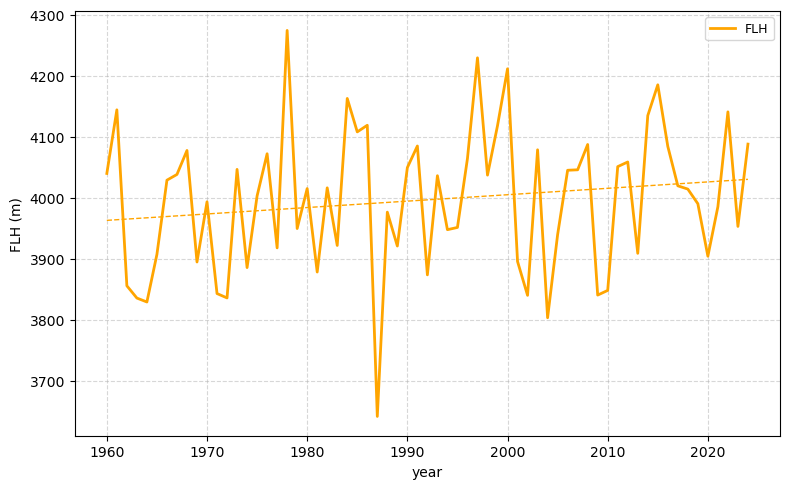

In [24]:
print(f'FLH : {slope_FLH * 10:.2f} m / decade (p={p_value_FLH:.3f}) ({(slope_FLH*10)/mean_FLH*100:.1f} %/decade) (std={std_FLH/mean_FLH*100:.1f} %)\n')

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(FLH_mean['year'].values, FLH_mean['FLH'].values, color='orange', label='FLH', linewidth=2)
ax.plot(FLH_mean['year'].values, trend_FLH, color='orange', linewidth=1, linestyle='--')

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel('year')
ax.set_ylabel('FLH (m)')

# --- legend
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Monthly timeseries

In [25]:
RF_monthly_timeseries = {}
SF_monthly_timeseries = {}
TF_monthly_timeseries = {}
R_monthly_timeseries = {}

for i in np.arange(1,13):
    
    # Selection of a single month through the all period
    RF_month = RF.sel(time=RF.time.dt.month == i)
    SF_month = SF.sel(time=SF.time.dt.month == i)
    TF_month = TF.sel(time=RF.time.dt.month == i)
    
    # Monthly mean for month i
    RF_monthly = RF_month.groupby('time.year').mean('time', skipna=True)
    RF_monthly = RF_monthly.mean(dim=['Y','X'], skipna=True)
    
    SF_monthly = SF_month.groupby('time.year').mean('time', skipna=True)
    SF_monthly = SF_monthly.mean(dim=['Y','X'], skipna=True)
    
    TF_monthly = TF_month.groupby('time.year').mean('time', skipna=True)
    TF_monthly = TF_monthly.mean(dim=['Y','X'], skipna=True)
    
    R_monthly = RF_monthly / SF_monthly * 100

    RF_monthly_timeseries[i] = RF_monthly
    SF_monthly_timeseries[i] = SF_monthly
    TF_monthly_timeseries[i] = TF_monthly
    R_monthly_timeseries[i] = R_monthly

# Monthly trends

In [26]:
RF_monthly_trends = {}
SF_monthly_trends = {}
TF_monthly_trends = {}
R_monthly_trends = {}

RF_monthly_trends_stats = {}
SF_monthly_trends_stats = {}
TF_monthly_trends_stats = {}
R_monthly_trends_stats = {}

for i in np.arange(1,13):

    RF_mask = ~np.isnan(RF_monthly_timeseries[i].values)
    slope_month_RF, intercept_month_RF, r_value_month_RF, p_value_month_RF, std_err_month_RF = stats.linregress(RF_monthly_timeseries[i]['year'].values[mask], RF_monthly_timeseries[i].values[mask])
    trend_month_RF = intercept_month_RF + slope_month_RF * RF_monthly_timeseries[i]['year'].values

    slope_month_SF, intercept_month_SF, r_value_month_SF, p_value_month_SF, std_err_month_SF = stats.linregress(SF_monthly_timeseries[i]['year'].values, SF_monthly_timeseries[i].values)
    trend_month_SF = intercept_month_SF + slope_month_SF * SF_monthly_timeseries[i]['year'].values
    
    slope_month_TF, intercept_month_TF, r_value_month_TF, p_value_month_TF, std_err_month_TF = stats.linregress(TF_monthly_timeseries[i]['year'].values, TF_monthly_timeseries[i].values)
    trend_month_TF = intercept_month_TF + slope_month_TF * TF_monthly_timeseries[i]['year'].values
    
    slope_month_R, intercept_month_R, r_value_month_R, p_value_month_R, std_err_month_R = stats.linregress(R_monthly_timeseries[i]['year'].values, R_monthly_timeseries[i].values)
    trend_month_R = intercept_month_R + slope_month_R * R_monthly_timeseries[i]['year'].values

    RF_monthly_trends_stats[i] = [slope_month_RF, intercept_month_RF, r_value_month_RF, p_value_month_RF, std_err_month_RF]
    SF_monthly_trends_stats[i] = [slope_month_SF, intercept_month_SF, r_value_month_SF, p_value_month_SF, std_err_month_SF]
    TF_monthly_trends_stats[i] = [slope_month_TF, intercept_month_TF, r_value_month_TF, p_value_month_TF, std_err_month_TF]
    R_monthly_trends_stats[i] = [slope_month_R, intercept_month_R, r_value_month_R, p_value_month_R, std_err_month_R]

    RF_monthly_trends[i] = trend_month_RF
    SF_monthly_trends[i] = trend_month_SF
    TF_monthly_trends[i] = trend_month_TF
    R_monthly_trends[i] = trend_month_R

# Monthly statistics

In [27]:
RF_monthly_stats = {}
SF_monthly_stats = {}
TF_monthly_stats = {}
R_monthly_stats = {}

for i in np.arange(1,13):

    mean_month_RF = np.nanmean(RF_monthly_timeseries[i].values)
    std_month_RF = np.nanstd(RF_monthly_timeseries[i].values)
    min_month_RF = np.nanmin(RF_monthly_timeseries[i].values)
    max_month_RF = np.nanmax(RF_monthly_timeseries[i].values)
    
    mean_month_SF = np.nanmean(SF_monthly_timeseries[i].values)
    std_month_SF = np.nanstd(SF_monthly_timeseries[i].values)
    min_month_SF = np.nanmin(SF_monthly_timeseries[i].values)
    max_month_SF = np.nanmax(SF_monthly_timeseries[i].values)
    
    mean_month_TF = np.nanmean(TF_monthly_timeseries[i].values)
    std_month_TF = np.nanstd(TF_monthly_timeseries[i].values)
    min_month_TF = np.nanmin(TF_monthly_timeseries[i].values)
    max_month_TF = np.nanmax(TF_monthly_timeseries[i].values)
    
    mean_month_R = np.nanmean(R_monthly_timeseries[i].values)
    std_month_R = np.nanstd(R_monthly_timeseries[i].values)
    min_month_R = np.nanmin(R_monthly_timeseries[i].values)
    max_month_R = np.nanmax(R_monthly_timeseries[i].values)

    RF_monthly_stats[i] = [mean_month_RF, std_month_RF, min_month_RF, max_month_RF]
    SF_monthly_stats[i] = [mean_month_SF, std_month_SF, min_month_SF, max_month_SF]
    TF_monthly_stats[i] = [mean_month_TF, std_month_TF, min_month_TF, max_month_TF]
    R_monthly_stats[i] = [mean_month_R, std_month_R, min_month_R, max_month_R]

==================================================== RF =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,0.00,29.8,0.00,219.9
Feb,0.00,13.9,0.00,158.2
Mar,0.00,23.3,0.01,104.5
Apr,-0.01,-3.5,0.19,82.2
May,0.05,4.4,0.66,64.2
Jun,0.16,13.9,0.88,77.1
Jul,0.16,9.2,1.49,85.5
Aug,0.22,18.0,1.32,105.4
Sep,0.01,6.7,0.11,57.8
Oct,0.00,8.5,0.03,88.0


==================================================== SF =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,0.79,2.2,13.68,38.5
Feb,0.81,1.8,15.71,34.3
Mar,-1.20,-2.0,19.05,31.1
Apr,-1.24,-2.0,18.39,29.1
May,-1.35,-2.1,23.37,36.3
Jun,3.06,8.0,21.88,57.6
Jul,-0.43,-2.4,15.66,87.6
Aug,0.96,9.6,8.82,87.5
Sep,0.14,1.4,7.03,73.4
Oct,-0.28,-1.1,15.38,60.4


==================================================== TF =================================================


,slope (mm/month/decade),slope (%/decade),std (mm/month),std (%)
Jan,0.79,2.2,13.68,38.5
Feb,0.81,1.8,15.71,34.3
Mar,-1.19,-2.0,19.05,31.1
Apr,-1.24,-2.0,18.42,29.0
May,-1.30,-2.0,23.63,36.2
Jun,3.22,8.2,22.44,57.4
Jul,-0.27,-1.4,16.52,84.2
Aug,1.19,10.5,9.47,83.6
Sep,0.15,1.5,7.07,72.4
Oct,-0.28,-1.1,15.39,60.4


==================================================== R =================================================


,slope (%/decade),std (%)
Jan,0.00,0.00
Feb,0.00,0.00
Mar,0.00,0.02
Apr,-0.00,0.36
May,0.10,0.95
Jun,0.15,1.70
Jul,1.33,12.43
Aug,1.16,22.52
Sep,0.13,3.37
Oct,0.02,0.11


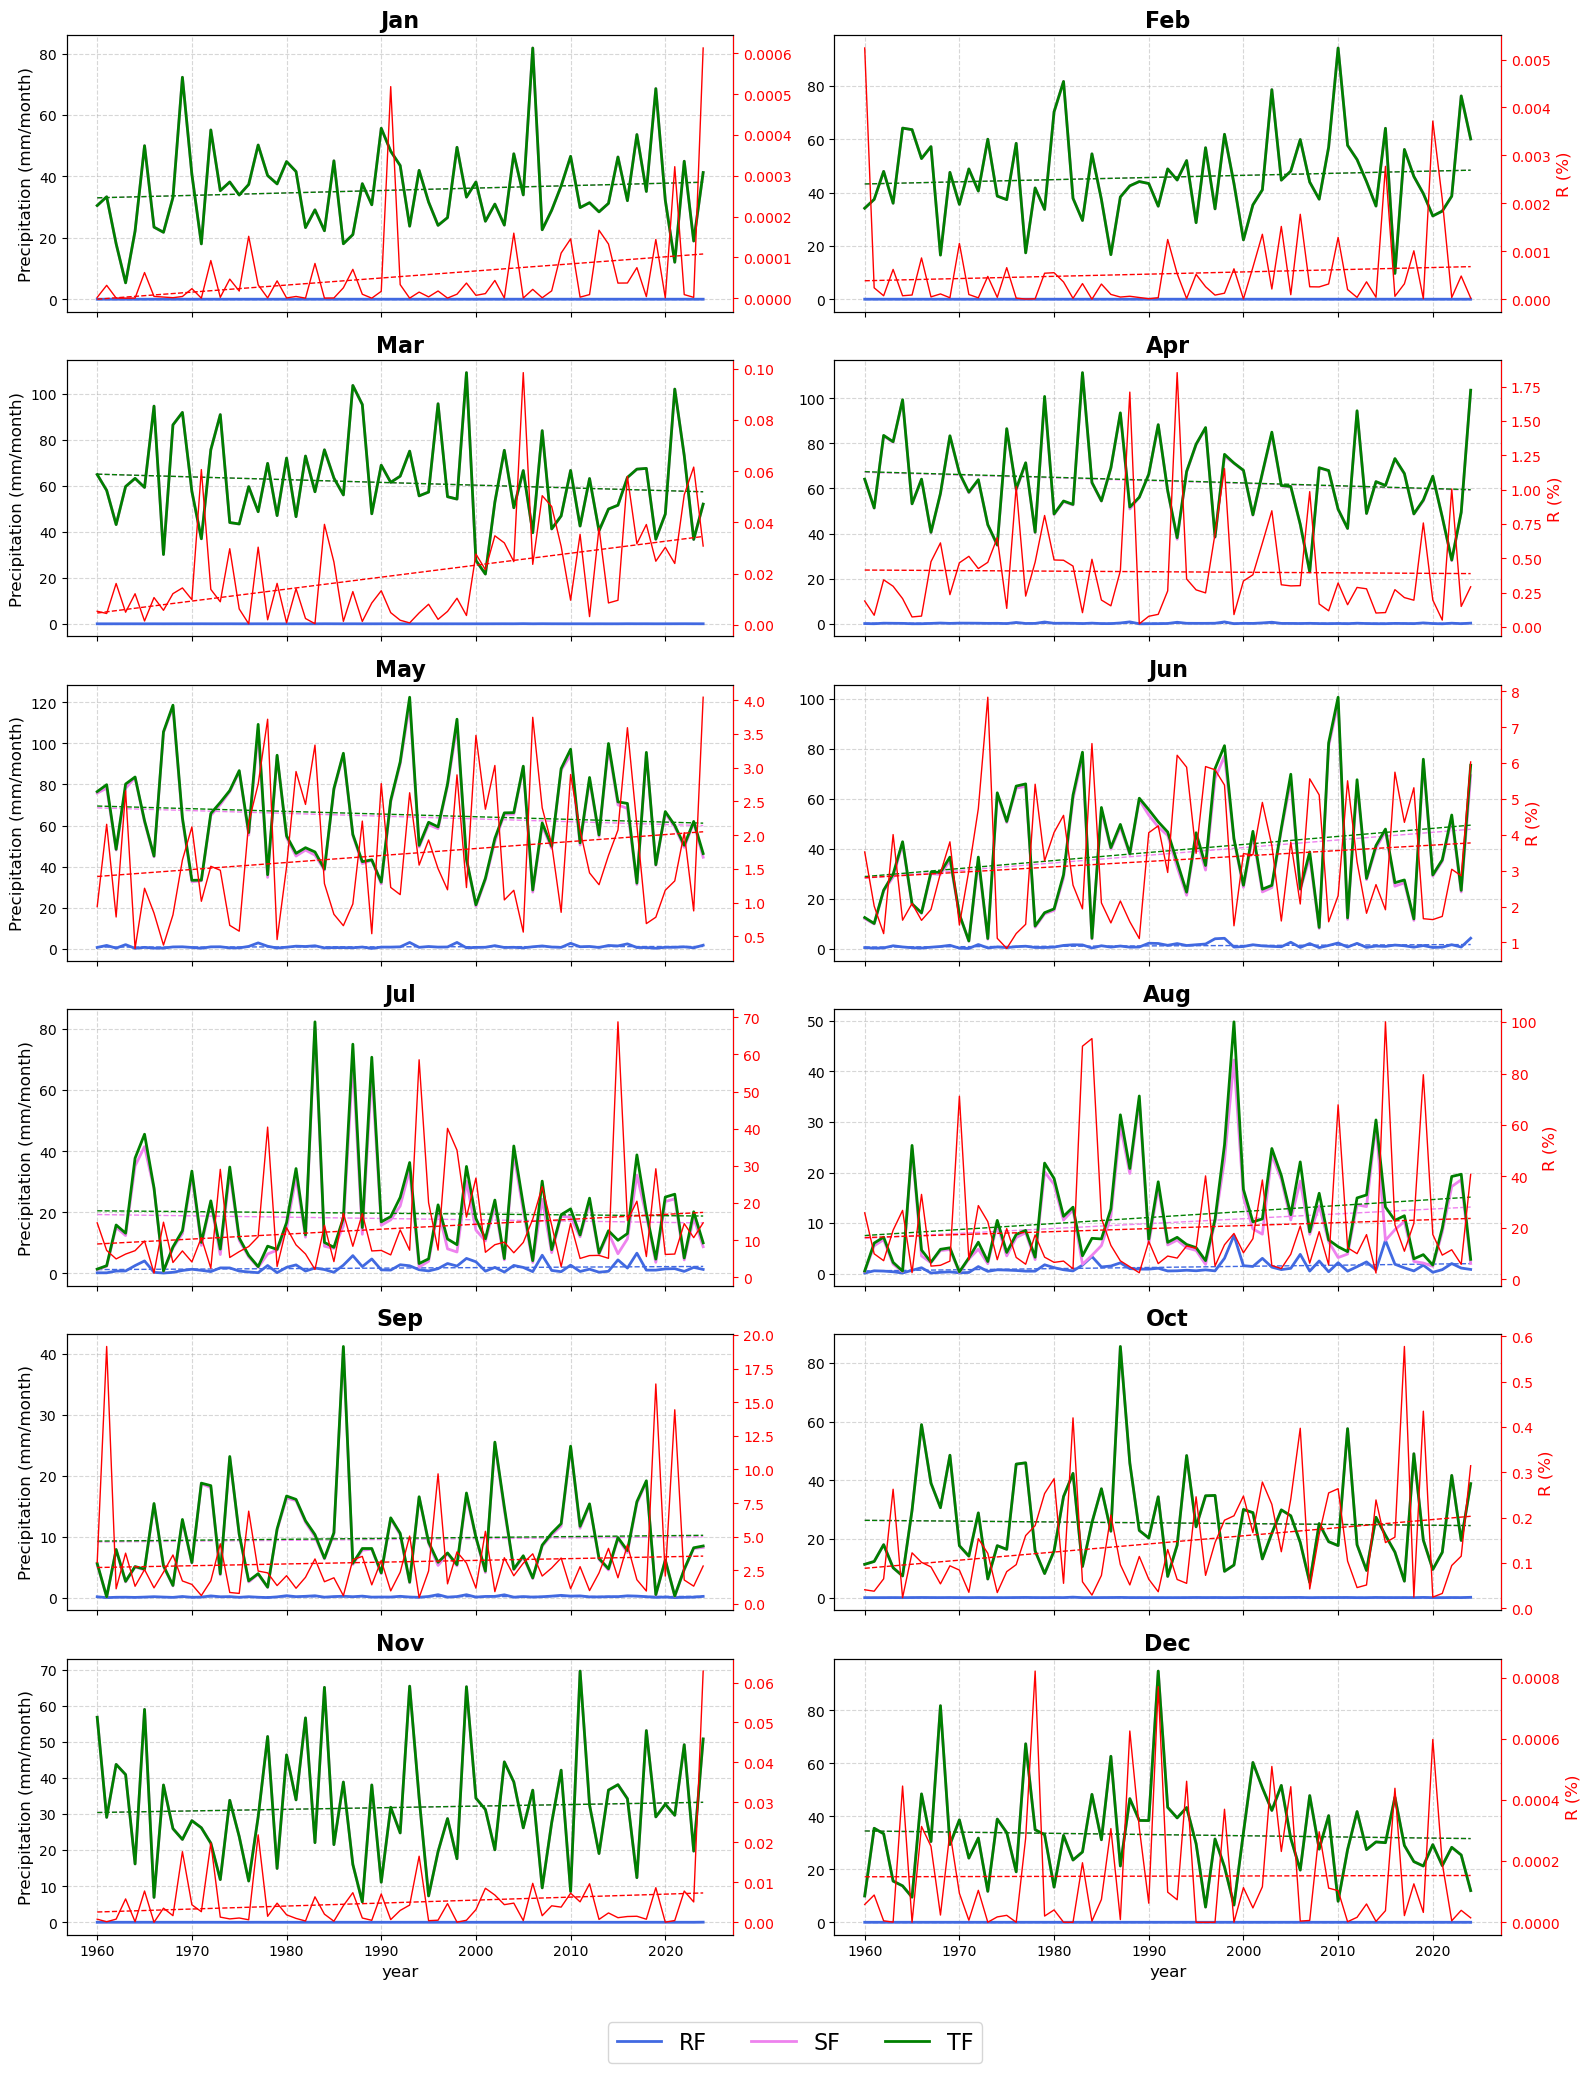

In [28]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

#====================== statistics tab ==============================================================================

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

#========= RF ================
print('==================================================== RF =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    RF_slope = RF_monthly_trends_stats[i][0] * 10
    RF_pval  = RF_monthly_trends_stats[i][3]
    RF_slope_percentage = RF_slope /  RF_monthly_stats[i][0] * 100
    RF_std = RF_monthly_stats[i][1]
    RF_std_percentage = RF_std /  RF_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = RF_slope
    table.loc[months[i-1], 'slope (%/decade)'] = RF_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = RF_std
    table.loc[months[i-1], 'std (%)'] = RF_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = RF_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = RF_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#========= SF ================
print('==================================================== SF =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    SF_slope = SF_monthly_trends_stats[i][0] * 10
    SF_pval  = SF_monthly_trends_stats[i][3]
    SF_slope_percentage = SF_slope /  SF_monthly_stats[i][0] * 100
    SF_std = SF_monthly_stats[i][1]
    SF_std_percentage = SF_std /  SF_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = SF_slope
    table.loc[months[i-1], 'slope (%/decade)'] = SF_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = SF_std
    table.loc[months[i-1], 'std (%)'] = SF_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = SF_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = SF_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#========= TF ================
print('==================================================== TF =================================================')

table = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (mm/month/decade)', 'slope (%/decade)', 'std (mm/month)', 'std (%)'])

for i in np.arange(1,13):

    TF_slope = TF_monthly_trends_stats[i][0] * 10
    TF_pval  = TF_monthly_trends_stats[i][3]
    TF_slope_percentage = TF_slope /  TF_monthly_stats[i][0] * 100
    TF_std = TF_monthly_stats[i][1]
    TF_std_percentage = TF_std /  TF_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (mm/month/decade)'] = TF_slope
    table.loc[months[i-1], 'slope (%/decade)'] = TF_slope_percentage
    table.loc[months[i-1], 'std (mm/month)'] = TF_std
    table.loc[months[i-1], 'std (%)'] = TF_std_percentage

    
    pvals.loc[months[i-1], 'slope (mm/month/decade)'] = TF_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = TF_pval

formats = {
    'slope (mm/month/decade)': "{:.2f}",
    'slope (%/decade)': "{:.1f}",
    'std (mm/month)': "{:.2f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#========= R ================
print('==================================================== R =================================================')

table = pd.DataFrame(index=months, columns=['slope (%/decade)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (%/decade)', 'std (%)'])

for i in np.arange(1,13):

    R_slope = R_monthly_trends_stats[i][0] * 10
    R_pval  = R_monthly_trends_stats[i][3]
    R_std = R_monthly_stats[i][1]

    table.loc[months[i-1], 'slope (%/decade)'] = R_slope
    table.loc[months[i-1], 'std (%)'] = R_std
    
    pvals.loc[months[i-1], 'slope (%/decade)'] = R_pval

formats = {
    'slope (%/decade)': "{:.2f}",
    'std (%)': "{:.2f}",      
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#======================== plot ============================================================================================

fig, axes = plt.subplots(6, 2, figsize=(16,20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    ax2 = ax.twinx()  # axe droit
    # mettre l'axe droit en red
    ax2.tick_params(axis='y', colors='red')
    ax2.yaxis.label.set_color('red')
    ax2.spines['right'].set_color('red')
    
    ax.plot(RF_monthly_timeseries[i+1]['year'].values, RF_monthly_timeseries[i+1].values, color='royalblue', label='RF', linewidth=2)
    ax.plot(RF_monthly_timeseries[i+1]['year'].values, RF_monthly_trends[i+1], color='royalblue', linewidth=1, linestyle='--')
    
    ax.plot(SF_monthly_timeseries[i+1]['year'].values, SF_monthly_timeseries[i+1].values, color='violet', label='SF', linewidth=2)
    ax.plot(SF_monthly_timeseries[i+1]['year'].values, SF_monthly_trends[i+1], color='violet', linewidth=1, linestyle='--')
    
    ax.plot(TF_monthly_timeseries[i+1]['year'].values, TF_monthly_timeseries[i+1].values, color='green', label='TF', linewidth=2)
    ax.plot(TF_monthly_timeseries[i+1]['year'].values, TF_monthly_trends[i+1], color='green', linewidth=1, linestyle='--')
    
    ax2.plot(R_monthly_timeseries[i+1]['year'].values, R_monthly_timeseries[i+1].values, color='red', label='R', linewidth=1)
    ax2.plot(R_monthly_timeseries[i+1]['year'].values, R_monthly_trends[i+1], color='red', linewidth=1, linestyle='--')

    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 2, 4, 6, 8, 10]:  # colonne gauche
        ax.set_ylabel('Precipitation (mm/month)', fontsize=12)

    if i in [1, 3, 5, 7, 9, 11]:  # colonne droite
        ax2.set_ylabel('R (%)', fontsize=12)
        
    if i in [10, 11]:  # ligne du bas
        ax.set_xlabel('year', fontsize=12)
    else:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
# --- legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
    
plt.tight_layout()
plt.show()

# Monthly evolution of freezing level height (FLH)

In [30]:
FLH_monthly_timeseries = {}

FLH_monthly_trends = {}
FLH_monthly_trends_stats = {}

FLH_monthly_stats = {}

for i in np.arange(1,13):

    # Selection du i-ème mois
    FLH_monthly = FLH[FLH.index.month == i] 
    FLH_monthly = FLH_monthly.groupby(FLH_monthly.index.year)['FLH'].mean().reset_index()
    FLH_monthly.columns = ['year', 'FLH']
    
    #trend
    # On ne garde que les lignes valides seulement si le résultat n'est pas vide
    if FLH_monthly['FLH'].notna().any():
        FLH_monthly = FLH_monthly[['year', 'FLH']].dropna()
        
    slope_month_FLH, intercept_month_FLH, r_value_month_FLH, p_value_month_FLH, std_err_month_FLH = stats.linregress(FLH_monthly['year'].values, FLH_monthly['FLH'].values)
    trend_month_FLH = intercept_month_FLH + slope_month_FLH * FLH_monthly['year'].values
    
    #statistics
    mean_month_FLH = np.mean(FLH_monthly['FLH'].values)
    std_month_FLH = np.std(FLH_monthly['FLH'].values)
    min_month_FLH = np.min(FLH_monthly['FLH'].values)
    max_month_FLH = np.max(FLH_monthly['FLH'].values)

    FLH_monthly_timeseries[i] = FLH_monthly

    FLH_monthly_trends[i] = trend_month_FLH
    FLH_monthly_trends_stats[i] = [slope_month_FLH, intercept_month_FLH, r_value_month_FLH, p_value_month_FLH, std_err_month_FLH]
    
    FLH_monthly_stats[i] = [mean_month_FLH, std_month_FLH, min_month_FLH, max_month_FLH]
    

,slope (m/decade),slope (%/decade),std (m),std (%)
Jan,-,-,-,-
Feb,-,-,-,-
Mar,14,0.5,120,4.3
Apr,18,0.5,165,5.0
May,28,0.7,179,4.7
Jun,15,0.3,182,4.1
Jul,18,0.4,135,2.8
Aug,7,0.1,105,2.1
Sep,34,0.8,176,4.1
Oct,30,0.9,211,6.4


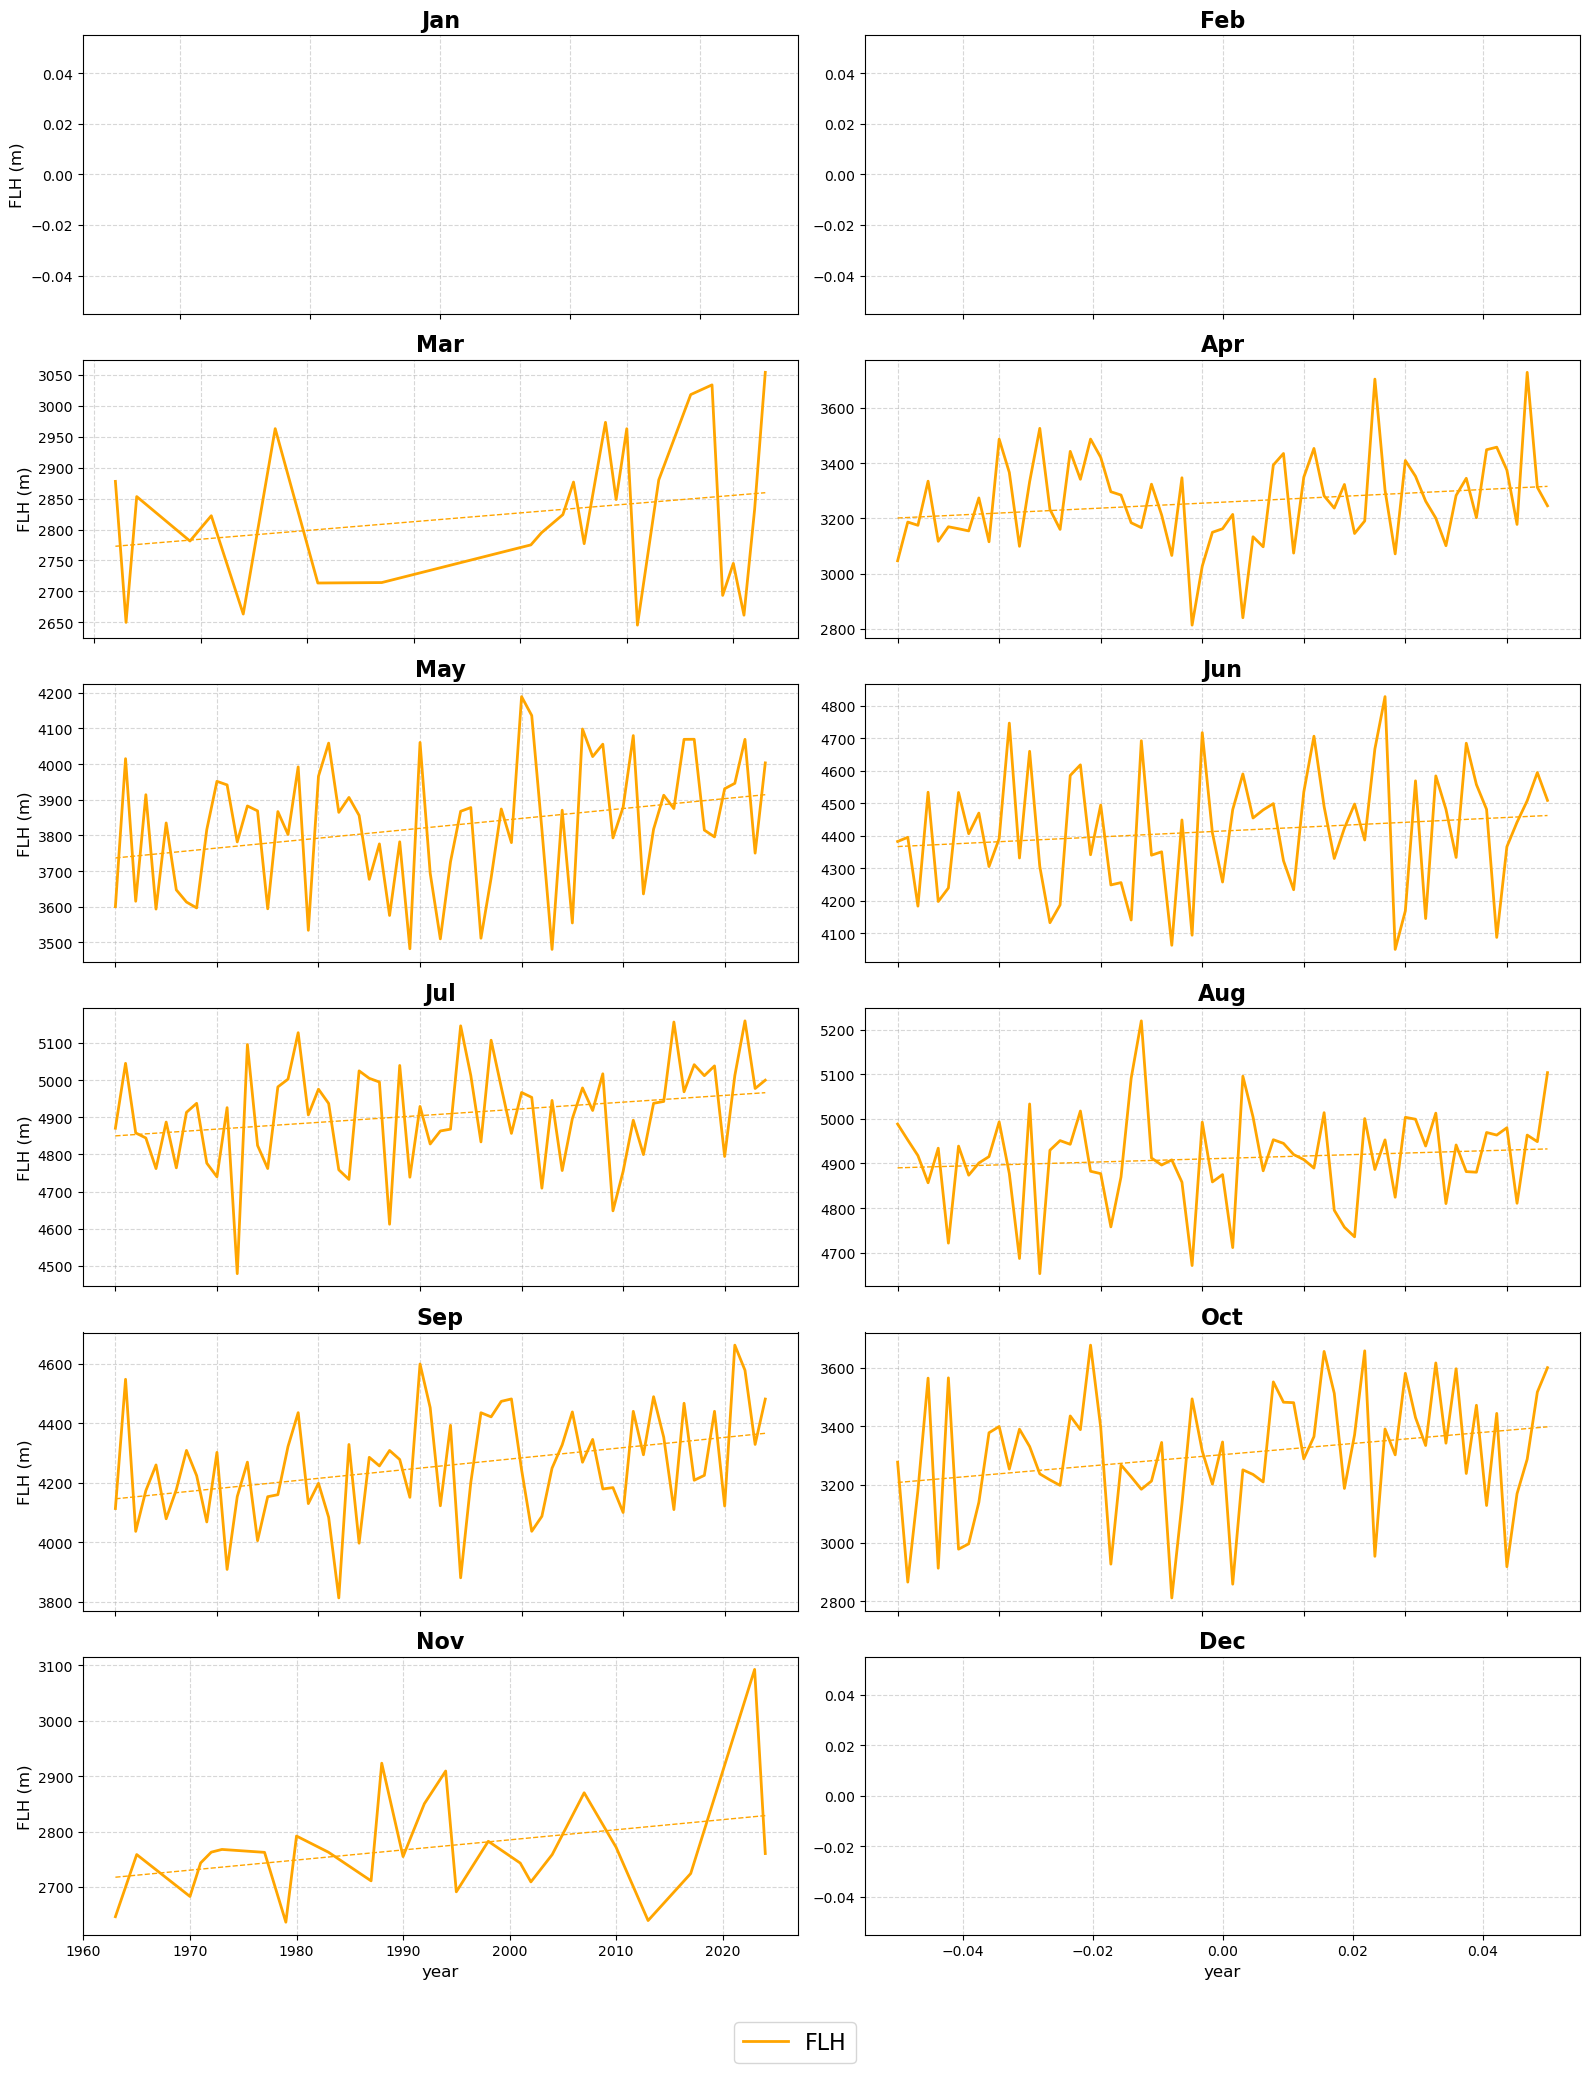

In [31]:
#====================== statistics tab ==============================================================================

table = pd.DataFrame(index=months, columns=['slope (m/decade)', 'slope (%/decade)', 'std (m)', 'std (%)'])
pvals = pd.DataFrame(index=months, columns=['slope (m/decade)', 'slope (%/decade)', 'std (m)', 'std (%)'])

for i in np.arange(1,13):

    FLH_slope = FLH_monthly_trends_stats[i][0] * 10
    FLH_pval  = FLH_monthly_trends_stats[i][3]
    FLH_slope_percentage = FLH_slope /  FLH_monthly_stats[i][0] * 100
    FLH_std = FLH_monthly_stats[i][1]
    FLH_std_percentage = FLH_std /  FLH_monthly_stats[i][0] * 100

    table.loc[months[i-1], 'slope (m/decade)'] = FLH_slope
    table.loc[months[i-1], 'slope (%/decade)'] = FLH_slope_percentage
    table.loc[months[i-1], 'std (m)'] = FLH_std
    table.loc[months[i-1], 'std (%)'] = FLH_std_percentage

    
    pvals.loc[months[i-1], 'slope (m/decade)'] = FLH_pval
    pvals.loc[months[i-1], 'slope (%/decade)'] = FLH_pval

def bold_sig(val, p):
    if p < 0.05:
        return 'font-weight: bold'
    return ''

formats = {
    'slope (m/decade)': "{:.0f}",
    'slope (%/decade)': "{:.1f}",
    'std (m)': "{:.0f}",      
    'std (%)': "{:.1f}"
}

styled_table = table.style.apply(
    lambda x: [bold_sig(v, pvals.loc[x.name, col]) for col, v in x.items()],
    axis=1
).format(formats, na_rep='-')

display(styled_table)

#======================== plot ============================================================================================

fig, axes = plt.subplots(6, 2, figsize=(16,20))
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    ax.plot(FLH_monthly_timeseries[i+1]['year'].values, FLH_monthly_timeseries[i+1]['FLH'].values, color='orange', label='FLH', linewidth=2)
    ax.plot(FLH_monthly_timeseries[i+1]['year'].values, FLH_monthly_trends[i+1], color='orange', linewidth=1, linestyle='--')

    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 2, 4, 6, 8, 10]:  # colonne gauche
        ax.set_ylabel('FLH (m)', fontsize=12)
        
    if i in [10, 11]:  # ligne du bas
        ax.set_xlabel('year', fontsize=12)
    else:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
# --- legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
    
plt.tight_layout()
plt.show()

# Representing evolution of FLH on elevation bins of ICE areas

# On Annual Mean

In [36]:
# Distribution des pixels selon l'altitude
dsSH=ds_grM.SH[nx:-nx,ny:-ny]
dsSH = dsSH.rename({'x': 'X', 'y': 'Y'})

ICE_mask = ICE_mask.assign_coords({
    "X": dsSH.X,
    "Y": dsSH.Y
})

ICE_areas = dsSH.where(ICE_mask)
elev_bands = np.arange(0, 8001, 250)
ICE_areas = ICE_areas.groupby_bins(ICE_areas, bins = elev_bands).count()
ICE_areas = ICE_areas * 49 # Convert to km2

In [37]:
# Mean over pas period (1960-1980) and present (2004-2024)
FLH_past = np.nanmean(FLH_mean[(FLH_mean['year'] >= 1960) & (FLH_mean['year'] <= 1980)]['FLH'].values)
FLH_present = np.nanmean(FLH_mean[(FLH_mean['year'] >= 2004) & (FLH_mean['year'] <= 2024)]['FLH'].values)

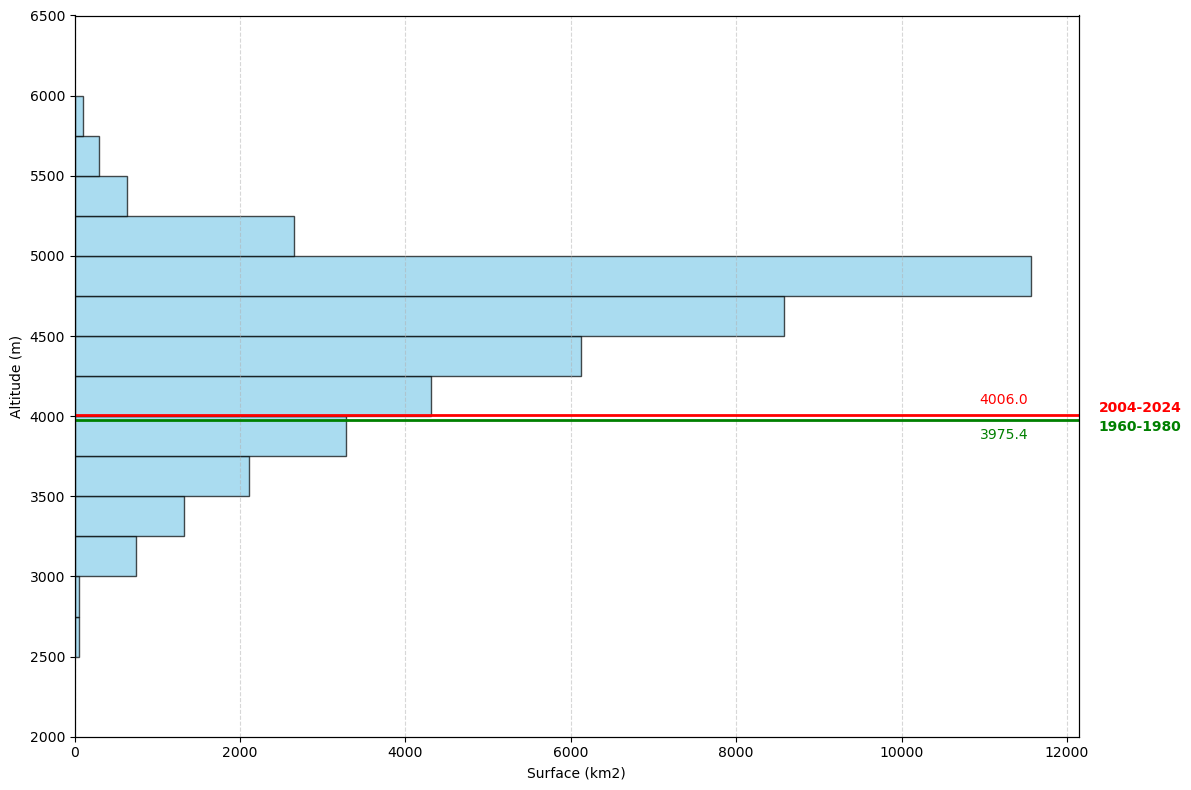

In [44]:
# Récupération des bords inférieurs des bandes pour l'axe Y
y_bottoms = [interval.left for interval in ICE_areas.SH_bins.values]
x_values = ICE_areas.values

# Tracé du bar plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Tracé du bar plot sur l'axe principal (gauche)
ax1.barh(y_bottoms, x_values, height=250, align='edge', color='skyblue', edgecolor='black', alpha=0.7)

# Réglages axe gauche
ax1.set_yticks(np.arange(0, 8001, 500))
ax1.set_ylim(2000, 6500)
ax1.set_xlabel("Surface (km2)")
ax1.set_ylabel("Altitude (m)")
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Création de l'axe secondaire (droite)
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim()) # On aligne les limites verticales

# Ajout des hlines et des labels 

if not np.isnan(FLH_past):
    # Tracer la ligne horizontale
    ax1.axhline(y=FLH_past, color='green', linestyle='-', linewidth=2, label='1960-1980')
        
    # Ajouter le nom de la période sur l'axe de droite
    # On place le texte à la hauteur de la ligne
    ax2.text(1.02, FLH_past, '1960-1980', transform=ax2.get_yaxis_transform(), color='green', fontweight='bold', va='top')
    ax2.text(0.95, FLH_past - 50, f'{FLH_past:.1f}', 
         transform=ax2.get_yaxis_transform(), 
         color='green', 
         fontweight='normal', 
         ha='right',  # Aligné à droite pour ne pas chevaucher la bordure
         va='top')
    
if not np.isnan(FLH_present):
    # Tracer la ligne horizontale
    ax1.axhline(y=FLH_present, color='red', linestyle='-', linewidth=2, label='2004-2024')
        
    # Ajouter le nom de la période sur l'axe de droite
    # On place le texte à la hauteur de la ligne
    ax2.text(1.02, FLH_present, '2004-2024', transform=ax2.get_yaxis_transform(), color='red', fontweight='bold', va='bottom')
    ax2.text(0.95, FLH_present + 50, f'{FLH_present:.1f}', 
         transform=ax2.get_yaxis_transform(), 
         color='red', 
         fontweight='normal', 
         ha='right',  # Aligné à droite pour ne pas chevaucher la bordure
         va='bottom')

# On cache les graduations par défaut de l'axe de droite pour ne pas surcharger
ax2.set_yticks([]) 

plt.tight_layout()
plt.show()